[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_3_LightCurves.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# ZTF DR24 Lightcurves with Nested-Pandas

In this notebook we'll show how to:
- Understand the NestedFrame concept for storing multi-epoch data ([nested-pandas docs](https://nested-pandas.readthedocs.io/))
- Load an already-nested HATS lightcurve catalog (ZTF DR24) from S3 with LSDB
- Access and filter nested sub-columns
- Apply cheap per-object statistics with `map_rows()` to pre-screen variable sources
- Run the expensive Lomb-Scargle periodogram only on the variable subset ([light-curve docs](https://light-curve.readthedocs.io/))
- Visualize a phase-folded lightcurve
- Save the results for downstream use

In [1]:
# do you need to install the packages?
# if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb nested-pandas light-curve s3fs

In [ ]:
import logging
import os
import warnings

import pandas as pd

# Must be set before importing packages that use numexpr
os.environ["NUMEXPR_MAX_THREADS"] = "2"

import dask
import light_curve as licu
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
from dask.distributed import Client
from lsdb import ConeSearch
from nested_pandas.datasets import generate_data
from matplotlib import rcParams

%matplotlib inline
warnings.simplefilter("ignore")
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 550
rcParams["font.size"] = 20
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 2
dask.config.set({"dataframe.convert-string": False})

print(f"lsdb {lsdb.__version__}, nested-pandas {npd.__version__}")

## Setup Dask Cluster

LSDB uses Dask for parallel, out-of-memory computation. We start a local cluster before loading any data.

In [3]:
client = Client(n_workers=1, memory_limit="10GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:8787/status


## Introduction to NestedFrame

Lightcurve catalogs have a natural two-level structure: each row is an object with scalar metadata (coordinates, IDs, summary statistics) plus a variable-length sequence of per-epoch measurements.

`nested-pandas` solves this with the **NestedFrame**, a pandas DataFrame where one or more columns hold a full sub-DataFrame of epochs for each object. Sub-columns are accessible with dot notation (`df["lightcurve.mag"]`), and standard pandas queries propagate into the nested structure automatically.

Let's see this with synthetic data first.

In [4]:
ndf = generate_data(50, 100, seed=1).rename({"nested": "lightcurve"}, axis=1)
ndf

a         b                                         lightcurve
0   0.417022  0.038734  [{t: 6.532898, flux: 77.388964, flux_error: 1....
1   0.720324  1.357671  [{t: 10.541162, flux: 82.03493, flux_error: 1....
..       ...       ...                                                ...
48  0.287775  0.005741  [{t: 11.19434, flux: 11.946375, flux_error: 1....
49  0.130029  1.234290  [{t: 0.25112, flux: 94.006251, flux_error: 1.0...

[50 rows x 3 columns]

In [5]:
# One object's full lightcurve as a DataFrame
ndf["lightcurve"][0]

,t,flux,flux_error,band
0,6.532898,77.388964,1.0,r
1,1.439486,55.886109,1.0,g
...,...,...,...,...
98,13.575110,76.549696,1.0,g
99,14.949946,14.803440,1.0,g


In [6]:
# Sub-column accessor across all objects
ndf["lightcurve.flux"]

0     77.388964
0     55.886109
        ...    
49    17.012447
49    86.404021
Name: flux, Length: 5000, dtype: double[pyarrow]

## Load ZTF DR24

The ZTF DR24 "enhanced" lightcurve catalog is hosted on IRSA's S3 storage in HATS format. Each row is one object in one CCD quadrant for one passband. The per-epoch measurements are already stored in a `lightcurve` nested column, so no conversion step is needed.

In [7]:
ZTF_PATH = "s3://ipac-irsa-ztf/ztf/enhanced/dr24/lc/hats/"

ztf_catalog = lsdb.open_catalog(ZTF_PATH)
ztf_catalog.dtypes

objectid                                         int64[pyarrow]
filterid                                          int8[pyarrow]
objra                                            float[pyarrow]
objdec                                           float[pyarrow]
lightcurve    nested<hmjd: [double], mag: [float], magerr: [...
dtype: object

In [8]:
cone = ConeSearch(ra=254.5, dec=35.3, radius_arcsec=20 * 60)

In [9]:
ztf_catalog = lsdb.open_catalog(ZTF_PATH, search_filter=cone)
ztf_catalog

,objectid,filterid,objra,objdec,lightcurve
npartitions=1,,,,,
"Order: 5, Pixel: 2378",int64[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],"nested<hmjd: [double], mag: [float], magerr: [..."


## Filtering on Nested Sub-Columns

`query()` understands the `nested_column.sub_column` syntax on both lazy LSDB catalogs and computed NestedFrames. We apply all filters lazily so that LSDB processes each partition once and only downloads what we need.

In [10]:
ztf_catalog = ztf_catalog.query("lightcurve.mag < 20.0 and lightcurve.catflags == 0")
ztf_catalog = ztf_catalog.query("lightcurve.len() >= 100")

## Pre-Screen for Variability

Not all lightcurves are variable; running a Lomb–Scargle periodogram on every object would be wasteful. We first compute a cheap variability statistic, `Chi2Pvar` from the [`light-curve`](https://light-curve.snad.space) package, and keep only objects whose scatter is inconsistent with pure noise.

`Chi2Pvar` is the p-value of the chi2-test under the null hypothesis H0: the lightcurve is constant. Small values ($p < 0.01$) mean the scatter significantly exceeds the measurement errors, i.e. the source is likely intrinsically variable. Large values (close to 1) are consistent with a non-variable source.

In [11]:
# First, we introduce a float32 time column, so all inputs are float32
ztf_catalog = ztf_catalog.map_partitions(
    lambda partition: partition.assign(
        **{"lightcurve.time": (partition["lightcurve.hmjd"] - 60_000).astype(np.float32)},
    )
)

In [ ]:
chi2_feat = licu.Chi2Pvar()

def compute_variability(time, mag, magerr):
    result = chi2_feat(time, mag, magerr)
    return {"chi2_pvar": result[0]}

ztf_catalog = ztf_catalog.map_rows(
    compute_variability,
    columns=["lightcurve.time", "lightcurve.mag", "lightcurve.magerr"],
    meta={"chi2_pvar": np.float32},
    row_container="args",
    append_columns=True,
)

In [13]:
ztf_catalog = ztf_catalog.query("chi2_pvar < 0.01")

## Period Finding with Lomb--Scargle Periodogram

`light-curve` package provides [`Periodogram`](https://light-curve.snad.space/features/periodogram/) which computes a Lomb--Scargle periodogram and returns the best period and its signal-to-noise ratio.


In [ ]:
min_period = 1.2
max_period = 50.0
pg = licu.Periodogram(
    peaks=1,
    fast=False,
    freqs=np.linspace(2*np.pi / max_period, 2*np.pi / min_period, 10_000),
    normalization='log',
)
print(f"Output feature names: {pg.names}")

In [15]:
def extract_period(time, mag, magerr):
    result = pg(time, mag, magerr)
    return {"period": result[0], "period_s2n": result[1]}

ztf_catalog = ztf_catalog.map_rows(
    extract_period,
    columns=["lightcurve.time", "lightcurve.mag", "lightcurve.magerr"],
    meta={"period": np.float32, "period_s2n": np.float32},
    row_container="args",
    append_columns=True,
)

## Run the pipeline and save the results

All filters and feature extraction have been defined lazily. `write_catalog` triggers the single distributed computation; each partition is processed once and written to disk in HATS format.

In [16]:
%%time
ztf_catalog.write_catalog("hats/ztf_dr24_periods/")

CPU times: user 5.84 s, sys: 2.18 s, total: 8.02 s
Wall time: 6min 4s


## Explore and Visualize

Now we load the saved catalog and inspect the results.

In [17]:
ztf_ndf = lsdb.open_catalog("hats/ztf_dr24_periods/").compute()
ztf_ndf.sort_values("period_s2n", ascending=False)

objectid  filterid       objra     objdec  \
_healpix_29                                                            
669413964797482923  681116300004568         1  254.588409  35.426373   
669413964797482923  681216300009149         2  254.588409  35.426373   
...                             ...       ...         ...        ...   
669455459473693257  681316300009855         3  254.797928  35.466156   
669408476425605722  681316300010345         3  254.757462  35.434158   

                                                           lightcurve  \
_healpix_29                                                             
669413964797482923  [{hmjd: 58203.40144, mag: 16.23522, magerr: 0....   
669413964797482923  [{hmjd: 58198.42249, mag: 15.470216, magerr: 0...   
...                                                               ...   
669455459473693257  [{hmjd: 58227.39698, mag: 12.016444, magerr: 0...   
669408476425605722  [{hmjd: 58227.39698, mag: 12.054444, magerr: 0...   

                    chi2_pvar     period  period_s2n  
_healpix_29                                           
669413964797482923        0.0  28.665215   63.863972  
669413964797482923        0.0  28.665215   59.354527  
...                       ...        ...         ...  
669455459473693257        0.0   2.431596    4.304254  
669408476425605722        0.0   4.170409    4.133907  

[3735 rows x 8 columns]

In [18]:
# One object's full lightcurve
ztf_ndf["lightcurve"].iloc[0]

,hmjd,mag,magerr,clrcoeff,catflags,time
0,58198.39511,19.089096,0.056888,0.085110,0,-1801.604858
1,58198.43606,19.086086,0.056758,0.092305,0,-1801.563965
...,...,...,...,...,...,...
1713,60965.12332,18.963308,0.051729,0.095807,0,965.123291
1714,60969.11779,19.021891,0.054065,0.095440,0,969.117798


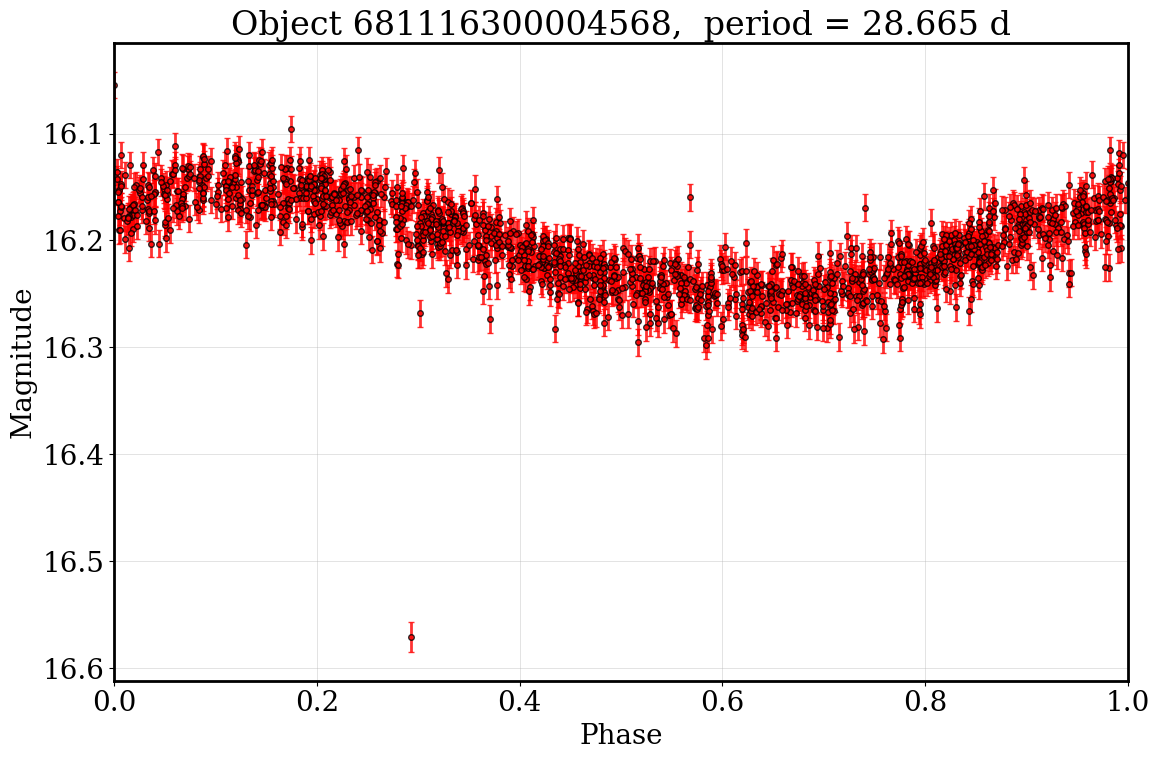

Check the object at the SNAD viewer: https://ztf.snad.space/view/681116300004568


In [19]:
interesting_idx = np.argmax(ztf_ndf["period_s2n"])

row = ztf_ndf.iloc[interesting_idx]
lc_data = row["lightcurve"]
period = row["period"]
objectid = row["objectid"]

peak_mjd = lc_data["hmjd"][lc_data["mag"].idxmin()]
lc_data["phase"] = (lc_data["hmjd"] - peak_mjd) % period / period

fig, ax = plt.subplots(figsize=(12, 8))
ax.errorbar(
    lc_data["phase"], lc_data["mag"], yerr=lc_data["magerr"],
    fmt="o", color="red", ecolor="red", elinewidth=2, capsize=2,
    alpha=0.8, markeredgecolor="k", markersize=4,
)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Phase")
ax.set_ylabel("Magnitude")
ax.set_title(f"Object {objectid},  period = {period:.3f} d")
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Check the object at the SNAD viewer: https://ztf.snad.space/view/{objectid}")

In [20]:
client.close()

## Problem 3

### Find a Transient with BazinFit

The Bazin function is an empirical model for transient light curves such as supernovae:

$$f(t) = A \cdot \frac{e^{-(t-t_0)/\tau_{\rm fall}}}{1 + e^{-(t-t_0)/\tau_{\rm rise}}} + B$$

The `light-curve` package provides [`BazinFit`](https://light-curve.snad.space/dev/features/api/fitting/#light_curve.BazinFit) to fit this model to each object's lightcurve. See the [fitting features overview](https://light-curve.snad.space/dev/features/fitting/) for more context.

**Steps:**
1. Load ZTF DR24 in a 20-arcmin cone around RA = 206 deg, Dec = +61.5 deg. Keep only objects with at least 100 good epochs (`catflags == 0`).
2. Convert magnitudes to flux ($f = 10^{-0.4\,m}$) so the Bazin rise is positive.
3. Apply `BazinFit` lazily to each lightcurve with `map_rows`.
4. Compute the results and find the object with the best fit (lowest reduced chi2).
5. Plot its lightcurve with the fitted Bazin curve overlaid.

A solution is in `Notebook_3_Solution.ipynb`. We will go over it together after the free-hacking time.